# Multi-session pooled SARSA

This notebook demonstrates `sarsa.multisession.fit_subject`: fitting several
sessions of one subject jointly so that chosen parameters are **shared** across
sessions while others stay **session-specific**.

We use a **sequential** task (a corridor with delayed reward) so that the
discount factor `gamma` is meaningful and identifiable — unlike a bandit, where
`gamma` has no effect. We:
1. simulate sessions from known `(alpha, beta, gamma)`,
2. fit a **pooled** model (shared `alpha`, `beta`; `gamma` fixed at its true
   value) and recover the parameters,
3. optionally estimate `gamma` too,
4. compare pooled vs **per-session** fits with BIC,
5. show **partial sharing** (shared `beta`, session-specific `alpha`).

## Sequential task: a corridor

Positions `0..3`. Two actions: **advance** (0) or **retreat** (1). Advancing
from the last position reaches the goal, delivers reward `1`, and resets to
position `0`; all other transitions give reward `0`. Reward is therefore
**delayed**, so value must propagate backward through positions — controlled by
`gamma`. Actions are sampled on-policy from `softmax(beta * Q[s])`.

Each session is an **independent learning episode** starting from `Q = 0`, so
when fitting we use `gap_rule="reset"` (Q is re-initialised at each session
boundary). Using `"carry"` here would misspecify the generative process.

In [1]:
import numpy as np
from scipy.special import softmax

from sarsa import sarsa
from sarsa import multisession as ms

L, N_ACT = 4, 2  # corridor positions 0..3; actions: 0=advance, 1=retreat


def step(p, a):
    """Environment transition: returns (next_position, reward)."""
    if a == 0:                              # advance
        if p == L - 1:
            return 0, 1.0                   # reach goal: reward, reset to start
        return p + 1, 0.0
    return max(p - 1, 0), 0.0               # retreat


def simulate_session(rng, params, q0, n_steps):
    """On-policy SARSA rollout in the corridor (independent episode from Q=0)."""
    alpha, beta, gamma = params
    q = q0.copy()
    p = 0
    a = int(rng.choice(N_ACT, p=softmax(beta * q[p])))
    quints = []
    for _ in range(n_steps):
        p2, r = step(p, a)
        a2 = int(rng.choice(N_ACT, p=softmax(beta * q[p2])))
        quints.append(sarsa.Quintuple(
            s1=np.array([p], dtype=int), a1=a, r2=r,
            s2=np.array([p2], dtype=int), a2=a2,
        ))
        q[p, a] += alpha * (r + gamma * q[p2, a2] - q[p, a])
        p, a = p2, a2
    return quints

In [2]:
rng = np.random.default_rng(0)

ALPHA_TRUE, BETA_TRUE, GAMMA_TRUE = 0.3, 3.0, 0.9
N_SESSIONS, N_STEPS = 6, 400
q0 = np.zeros((L, N_ACT))  # (n_positions, n_actions)

sessions = [
    simulate_session(rng, (ALPHA_TRUE, BETA_TRUE, GAMMA_TRUE), q0, N_STEPS)
    for _ in range(N_SESSIONS)
]
print(f'{len(sessions)} sessions x {N_STEPS} steps '
      f'= {sum(len(s) for s in sessions)} total trials')

6 sessions x 400 steps = 2400 total trials


## Pooled fit

Share all three canonical parameters across sessions. `gamma` is fixed at its
true value via `static_params` (it is the hardest to identify; we estimate it
separately below), and `fit_beta=True` lets `beta` be estimated. `gap_rule=
"reset"` matches the independent-episode generative process.

In [3]:
import warnings
warnings.simplefilter('ignore')  # silence boundary diagnostics for the demo

pooled = ms.fit_subject(
    sessions,
    q0=q0,
    p0=np.array([0.2, 1.5, GAMMA_TRUE]),
    share_mask=[True, True, True],
    static_params=[None, None, GAMMA_TRUE],  # fix gamma at its true value
    fit_beta=True,
    gap_rule='reset',                         # independent episodes
)

alpha_hat, beta_hat, _ = pooled.session_params[0]
print('Parameter recovery (shared across all sessions):')
print(f'  alpha: true={ALPHA_TRUE:.3f}  est={alpha_hat:.3f}')
print(f'  beta : true={BETA_TRUE:.3f}  est={beta_hat:.3f}')
print(f'  pooled loss (mean CE): {pooled.loss:.4f}')

Parameter recovery (shared across all sessions):
  alpha: true=0.300  est=0.286
  beta : true=3.000  est=2.965
  pooled loss (mean CE): 0.3729


## Estimating gamma (harder)

`gamma` is identified here through the *geometric decay of preference with
distance to the goal*, but it is weakly identified and noisier than `alpha` /
`beta`. Leaving its `static_params` slot as `None` estimates it jointly.

In [4]:
pooled_g = ms.fit_subject(
    sessions,
    q0=q0,
    p0=np.array([0.2, 1.5, 0.5]),
    share_mask=[True, True, True],
    static_params=None,        # estimate alpha, beta, AND gamma
    fit_beta=True,
    gap_rule='reset',
)
a_g, b_g, g_g = pooled_g.session_params[0]
print('Joint recovery including gamma:')
print(f'  alpha: true={ALPHA_TRUE:.3f}  est={a_g:.3f}')
print(f'  beta : true={BETA_TRUE:.3f}  est={b_g:.3f}')
print(f'  gamma: true={GAMMA_TRUE:.3f}  est={g_g:.3f}')

Joint recovery including gamma:
  alpha: true=0.300  est=0.287
  beta : true=3.000  est=2.931
  gamma: true=0.900  est=0.903


## Pooled vs per-session (BIC)

Both models are scored on the same pooled dataset of `N` trials. The
per-session model nests the pooled one, so its in-sample NLL is always lower;
BIC's `k * ln(N)` penalty is what favors the simpler, true generating model.
(`gamma` fixed at its true value in both; per-session fits start from `Q=0`,
matching `gap_rule="reset"`.)

In [5]:
n_total = sum(len(s) for s in sessions)
static = [None, None, GAMMA_TRUE]
p0 = np.array([0.2, 1.5, GAMMA_TRUE])

def bic(total_nll, k):
    return k * np.log(n_total) + 2 * total_nll

# Pooled: 2 free params (alpha, beta).
pooled_nll = pooled.loss * n_total
pooled_bic = bic(pooled_nll, k=2)

# Per-session: 2 free params each (fresh Q per session).
per_session_params, per_session_nll = [], 0.0
for session in sessions:
    params, loss, _, _ = sarsa.fit(
        session, q0=q0, p0=p0, static_params=static, fit_beta=True,
    )
    per_session_params.append(params)
    per_session_nll += loss * len(session)
per_session_bic = bic(per_session_nll, k=2 * len(sessions))

print(f'{"model":<14}{"k":>4}{"NLL":>12}{"BIC":>12}')
print(f'{"pooled":<14}{2:>4}{pooled_nll:>12.2f}{pooled_bic:>12.2f}')
print(f'{"per-session":<14}{2*len(sessions):>4}{per_session_nll:>12.2f}{per_session_bic:>12.2f}')
print()
print('pooled preferred' if pooled_bic < per_session_bic else 'per-session preferred')

model            k         NLL         BIC
pooled           2      895.00     1805.56
per-session     12      884.75     1862.90

pooled preferred


## Per-session estimates vs shared truth

Per-session MLEs scatter around the true value due to sampling noise; the
pooled estimate (dashed) is a single, tighter estimate.

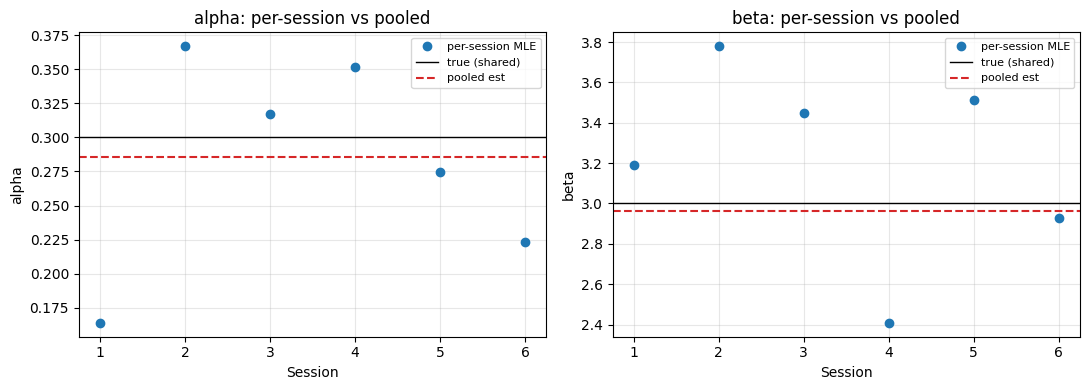

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

ps = np.array(per_session_params)
x = np.arange(1, len(sessions) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, idx, name, truth, pooled_val in [
    (axes[0], 0, 'alpha', ALPHA_TRUE, alpha_hat),
    (axes[1], 1, 'beta',  BETA_TRUE,  beta_hat),
]:
    ax.plot(x, ps[:, idx], 'o', label='per-session MLE')
    ax.axhline(truth, color='k', lw=1, label='true (shared)')
    ax.axhline(pooled_val, color='tab:red', ls='--', lw=1.5, label='pooled est')
    ax.set_xlabel('Session')
    ax.set_ylabel(name)
    ax.set_title(f'{name}: per-session vs pooled')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Partial sharing

Set `share_mask=[False, True, False]` to share `beta` across sessions
(a subject-level policy temperature) while `alpha` and `gamma` vary per
session — useful when the learning rate drifts day to day but choice
stochasticity is stable. Here `gamma` is held at its true value per session.

In [7]:
partial = ms.fit_subject(
    sessions,
    q0=q0,
    p0=np.array([0.2, 1.5, GAMMA_TRUE]),
    share_mask=[False, True, False],  # beta shared; alpha, gamma session-specific
    static_params=[None, None, GAMMA_TRUE],  # gamma fixed at its true value
    fit_beta=True,
    gap_rule='reset',
)
print('shared beta (subject-level):', np.round(partial.shared_params, 3))
print('per-session alpha:',
      np.round([p[sarsa.ParamIndex.alpha] for p in partial.session_params], 3))

shared beta (subject-level): [3.12]
per-session alpha: [0.168 0.38  0.34  0.24  0.3   0.208]
